# Fig: Infotaxis, mismatch agentLower scenario: pmax_th=0.95

Reference: 
- `20251230_fig_mismatch_agent_truth_efficiency_comparison.ipynb`
- `20260515_fig_mismatch_agent_truth_efficiency_comparison_agentHigher_pmax0.95.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from plot_utils import bar_violinplot_path_length
from simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  989    right:  926
Mean:    left: 42.833  right: 41.925
Median:  left: 37.000  right: 37.000

MWU test
 - different: 0.62157
 - less:      0.68925
 - greater:   0.31078
--------------------------------------------
Samples: left:  989    right:  832
Mean:    left: 42.833  right: 41.833
Median:  left: 37.000  right: 36.500

MWU test
 - different: 0.73648
 - less:      0.63179
 - greater:   0.36824
--------------------------------------------
Samples: left:  989    right:  618
Mean:    left: 42.833  right: 39.147
Median:  left: 37.000  right: 32.000

MWU test
 - different: 0.00505
 - less:      0.99748
 - greater:   0.00253
--------------------------------------------
Samples: left:  989    right:  245
Mean:    left: 42.833  right: 26.869
Median:  left: 37.000  right: 21.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


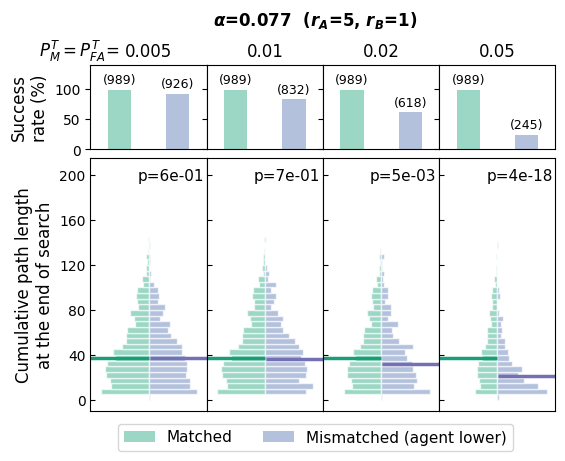

Samples: left:  977    right:  890
Mean:    left: 28.538  right: 29.236
Median:  left: 26.000  right: 26.000

MWU test
 - different: 0.33225
 - less:      0.16613
 - greater:   0.83390
--------------------------------------------
Samples: left:  977    right:  738
Mean:    left: 28.538  right: 29.610
Median:  left: 26.000  right: 26.000

MWU test
 - different: 0.32887
 - less:      0.16444
 - greater:   0.83559
--------------------------------------------
Samples: left:  977    right:  460
Mean:    left: 28.538  right: 28.289
Median:  left: 26.000  right: 26.000

MWU test
 - different: 0.46165
 - less:      0.76922
 - greater:   0.23083
--------------------------------------------
Samples: left:  977    right:  109
Mean:    left: 28.538  right: 19.798
Median:  left: 26.000  right: 18.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


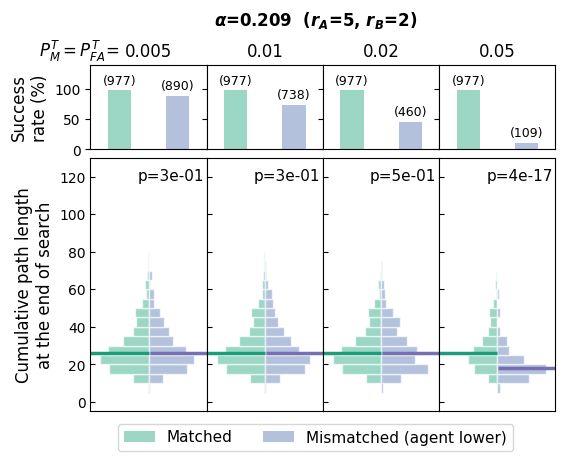

Samples: left:  986    right:  886
Mean:    left: 253.143  right: 234.343
Median:  left: 226.000  right: 204.000

MWU test
 - different: 0.01753
 - less:      0.99124
 - greater:   0.00876
--------------------------------------------
Samples: left:  986    right:  707
Mean:    left: 253.143  right: 227.136
Median:  left: 226.000  right: 196.000

MWU test
 - different: 0.00134
 - less:      0.99933
 - greater:   0.00067
--------------------------------------------
Samples: left:  986    right:  344
Mean:    left: 253.143  right: 171.032
Median:  left: 226.000  right: 140.500

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  986    right:   91
Mean:    left: 253.143  right: 58.473
Median:  left: 226.000  right: 38.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


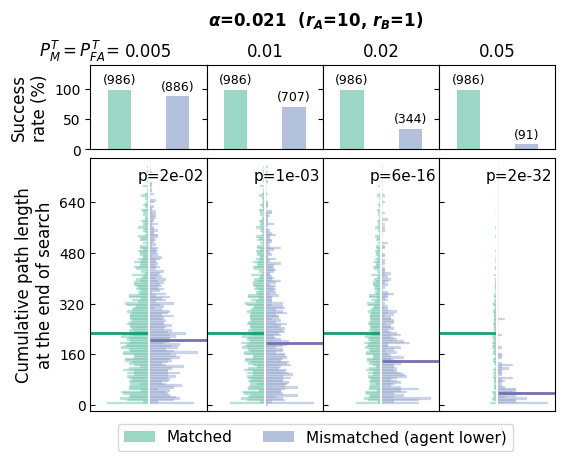

Samples: left:  980    right:  862
Mean:    left: 108.593  right: 103.669
Median:  left: 94.500  right: 92.000

MWU test
 - different: 0.29605
 - less:      0.85199
 - greater:   0.14803
--------------------------------------------
Samples: left:  980    right:  620
Mean:    left: 108.593  right: 97.665
Median:  left: 94.500  right: 87.000

MWU test
 - different: 0.00258
 - less:      0.99871
 - greater:   0.00129
--------------------------------------------
Samples: left:  980    right:  265
Mean:    left: 108.593  right: 65.426
Median:  left: 94.500  right: 51.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  980    right:   33
Mean:    left: 108.593  right: 26.333
Median:  left: 94.500  right: 23.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


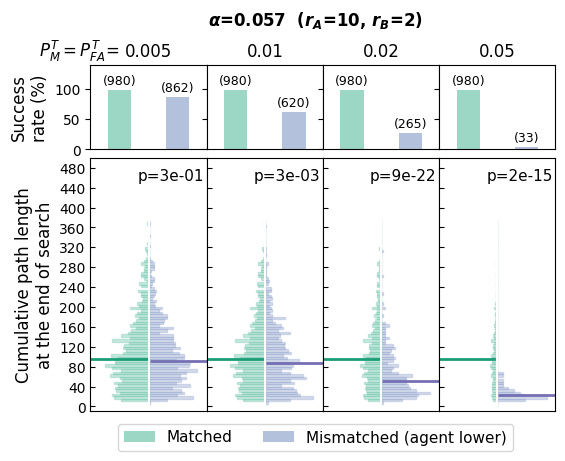

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_truth_all = [0.005, 0.01, 0.02, 0.05]
pm_agent_all = [0.001] * len(pm_truth_all)

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_infotaxis_mismatch_agentLower_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for idx, (pm_agent, pm_truth) in enumerate(zip(pm_agent_all, pm_truth_all)):
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="mismatch",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent, pm_truth=pm_truth
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)

        fig = bar_violinplot_path_length(
            cr=cr, br=br, pm_all=pm_truth_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Matched", y_str="Mismatched (agent lower)",
            stats_type="two-sided",
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            color_idx_left=0, color_idx_right=2,
            print_stats=True,
            comparison_type="agent_lower",
        )

        fig.savefig(
            path_fig / f"fig_path_length_mismatch_agentLower_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5_infotaxis.png",
            dpi=300, bbox_inches="tight"
        )